In [1]:
# ============================================================
# HETEROGENEOUS FLEET VRPTW
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [2]:
# ------------------------------------------------------------
# STEP 1: DEFINE JOB SITES
# ------------------------------------------------------------
LOCATIONS = {
    "names": [
        "Depot (HQ)",   # 0
        "Site A",       # 1
        "Site B",       # 2
        "Site C",       # 3
        "Site D",       # 4
        "Site E",       # 5
        "Site F",       # 6
        "Site G",       # 7
        "Site H",       # 8
        "Site I",       # 9
        "Site J",       # 10
    ],
    "coordinates": [
        (5, 5),   # 0 Depot
        (2, 9),   # 1 Site A
        (8, 9),   # 2 Site B
        (1, 6),   # 3 Site C
        (9, 6),   # 4 Site D
        (3, 3),   # 5 Site E
        (7, 3),   # 6 Site F
        (4, 7),   # 7 Site G
        (6, 7),   # 8 Site H
        (4, 4),   # 9 Site I
        (6, 4),   # 10 Site J
    ],
    "demands": [0, 2, 8, 3, 12, 2, 9, 3, 2, 7, 3],
    # Demands are higher here to stress-test vehicle assignment

    "time_windows": [
        (0,   480),  # 0  Depot
        (0,   120),  # 1  Site A
        (60,  240),  # 2  Site B
        (0,   120),  # 3  Site C
        (120, 300),  # 4  Site D
        (60,  240),  # 5  Site E
        (180, 360),  # 6  Site F
        (0,   180),  # 7  Site G
        (120, 300),  # 8  Site H
        (240, 420),  # 9  Site I
        (300, 480),  # 10 Site J
    ],
    "service_times": [0, 30, 45, 30, 60, 30, 45, 30, 30, 45, 30],
}

In [3]:
FLEET = [
    {
        "name":      "Light van",
        "capacity":  10,      # max load units
        "speed":     1.4,     # faster — smaller vehicle
        "cost_per_unit": 1,   # cheapest to run
        "color":     "#2196F3",
    },
    {
        "name":      "Medium truck",
        "capacity":  20,      # medium load
        "speed":     1.0,     # standard speed
        "cost_per_unit": 2,   # medium cost
        "color":     "#FF5722",
    },
    {
        "name":      "Heavy lorry",
        "capacity":  35,      # can carry the most
        "speed":     0.7,     # slower — heavy vehicle
        "cost_per_unit": 3,   # most expensive
        "color":     "#4CAF50",
    },
]

In [4]:
# ------------------------------------------------------------
# STEP 3: COMPUTE MATRICES
# ------------------------------------------------------------
def compute_distance_matrix(coordinates):
    """Standard Euclidean distance matrix (x100 for integers)."""
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            dist = math.hypot(x2 - x1, y2 - y1) * 100
            row.append(int(dist))
        matrix.append(row)
    return matrix


def compute_time_matrix_for_vehicle(coordinates, speed):
    """
    Travel time matrix for a SPECIFIC vehicle speed.
    Each vehicle gets its own time matrix because they move
    at different speeds — this is what makes the fleet heterogeneous
    in terms of time tracking.
    """
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            travel_time = math.hypot(x2 - x1, y2 - y1) / speed
            row.append(int(travel_time))
        matrix.append(row)
    return matrix


def compute_cost_matrix(distance_matrix, cost_per_unit):
    """
    Cost matrix for a specific vehicle type.
    Cost = distance × cost_per_unit.
    OR-Tools minimizes total cost — so expensive vehicles
    get assigned shorter or lighter routes automatically.
    """
    return [[int(dist * cost_per_unit) for dist in row]for row in distance_matrix]

In [5]:
# ------------------------------------------------------------
# STEP 4: BUILD DATA MODEL
# ------------------------------------------------------------
def create_data_model():
    data = {}
    coords = LOCATIONS["coordinates"]

    data["coordinates"]   = coords
    data["names"]         = LOCATIONS["names"]
    data["demands"]       = LOCATIONS["demands"]
    data["time_windows"]  = LOCATIONS["time_windows"]
    data["service_times"] = LOCATIONS["service_times"]
    data["num_vehicles"]  = len(FLEET)
    data["depot"]         = 0
    data["max_time"]      = 480
    data["fleet"]         = FLEET

    # Each vehicle gets its own capacity
    data["vehicle_capacities"] = [v["capacity"] for v in FLEET]

    # Shared distance matrix (geometry doesn't change per vehicle)
    data["distance_matrix"] = compute_distance_matrix(coords)

    # Each vehicle gets its own time matrix (speed differs)
    data["time_matrices"] = [
        compute_time_matrix_for_vehicle(coords, v["speed"])
        for v in FLEET
    ]

    # Each vehicle gets its own cost matrix
    data["cost_matrices"] = [
        compute_cost_matrix(data["distance_matrix"], v["cost_per_unit"])
        for v in FLEET
    ]

    return data


In [6]:
data = create_data_model()

manager = pywrapcp.RoutingIndexManager(
    len(data["distance_matrix"]),
    data["num_vehicles"],
    data["depot"]
    )

routing = pywrapcp.RoutingModel(manager)

In [7]:
# ------------------------------------------------------------
# STEP 5: EXTRACT ROUTES
# ------------------------------------------------------------
def extract_routes(data, manager, routing, solution, time_dimension):
    routes = []
    for vehicle_id in range(data["num_vehicles"]):
        index          = routing.Start(vehicle_id)
        route_nodes    = []
        route_arrivals = []
        route_distance = 0
        route_load     = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data["demands"][node]

            time_var = time_dimension.CumulVar(index)
            route_arrivals.append(solution.Min(time_var))

            prev  = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                prev, index, vehicle_id
            )

        route_nodes.append(0)
        time_var = time_dimension.CumulVar(index)
        route_arrivals.append(solution.Min(time_var))

        vehicle = data["fleet"][vehicle_id]
        routes.append({
            "vehicle_id":   vehicle_id,
            "vehicle_name": vehicle["name"],
            "capacity":     vehicle["capacity"],
            "speed":        vehicle["speed"],
            "color":        vehicle["color"],
            "nodes":        route_nodes,
            "arrivals":     route_arrivals,
            "distance":     route_distance,
            "load":         route_load,
        })
    return routes

In [8]:
# ------------------------------------------------------------
# STEP 6: HELPER
# ------------------------------------------------------------
def mins_to_clock(minutes):
    total = 8 * 60 + minutes
    h = total // 60
    m = total % 60
    return f"{h:02d}:{m:02d}"

In [9]:
# ------------------------------------------------------------
# STEP 7: PRINT SOLUTION
# ------------------------------------------------------------
def print_solution(data, routes):
    print("\n" + "="*65)
    print("  HETEROGENEOUS FLEET VRPTW SOLUTION")
    print("="*65)
    total_cost = 0

    for r in routes:
        print(f"\n  {r['vehicle_name']} "
              f"(capacity: {r['capacity']}  speed: {r['speed']}x)")

        if len(r["nodes"]) <= 1:
            print("     Not used in this solution")
            continue

        for idx, node in enumerate(r["nodes"]):
            arrival    = r["arrivals"][idx]
            window     = data["time_windows"][node]
            name       = data["names"][node]
            clock      = mins_to_clock(arrival)
            window_str = f"(window: {mins_to_clock(window[0])}-{mins_to_clock(window[1])})"
            print(f"     {name:15s}  arrive: {clock}  {window_str}")

        print(f"     ---")
        print(f"     Load    : {r['load']} / {r['capacity']} units")
        print(f"     Distance: {r['distance'] / 100:.2f} units")
        total_cost += r["distance"]

    print("\n" + "-"*65)
    print(f"  Total weighted cost: {total_cost}")
    print("="*65 + "\n")

In [10]:
# ------------------------------------------------------------
# STEP 8: VISUALIZE
# ------------------------------------------------------------
def visualize_routes(data, routes):
    fig, ax = plt.subplots(figsize=(10, 9))
    coords  = data["coordinates"]

    for r in routes:
        if len(r["nodes"]) <= 1:
            continue
        nodes = r["nodes"]
        for i in range(len(nodes) - 1):
            x1, y1 = coords[nodes[i]]
            x2, y2 = coords[nodes[i + 1]]
            ax.annotate(
                "",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=r["color"],
                    lw=2.2,
                    connectionstyle="arc3,rad=0.08"
                )
            )

    # Depot
    dx, dy = coords[0]
    ax.plot(dx, dy, marker="*", markersize=20,
            color="#FFD700", markeredgecolor="#555", zorder=5)
    ax.annotate("Depot (HQ)", (dx, dy),
                textcoords="offset points", xytext=(8, 8),
                fontsize=9, fontweight="bold")

    # Job sites
    for i in range(1, len(coords)):
        x, y   = coords[i]
        tw     = data["time_windows"][i]
        window = f"{mins_to_clock(tw[0])}-{mins_to_clock(tw[1])}"
        ax.plot(x, y, "o", markersize=16, color="white",
                markeredgecolor="#555", markeredgewidth=1.5, zorder=4)
        ax.text(x, y, str(data["demands"][i]),
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="#333", zorder=5)
        ax.annotate(
            f"{data['names'][i]}\n{window}",
            (x, y),
            textcoords="offset points", xytext=(10, 6),
            fontsize=7.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", ec="#ccc", alpha=0.8)
        )

    # Legend
    legend_handles = [
        mpatches.Patch(
            color=r["color"],
            label=(f"{r['vehicle_name']}  |  "
                   f"cap: {r['capacity']}  speed: {r['speed']}x  |  "
                   f"load: {r['load']}/{r['capacity']}")
        )
        for r in routes if len(r["nodes"]) > 1
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=8.5, framealpha=0.9)

    ax.set_title(
        "Heterogeneous Fleet VRPTW — Engineering Firm\n"
        "(circle numbers = demand  |  labels show time windows)",
        fontsize=12, pad=14
    )
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("heterogeneous_fleet_routes.png", dpi=150, bbox_inches="tight")
    print("  Route map saved as: heterogeneous_fleet_routes.png\n")
    plt.show()

In [11]:
            # --- Cost callback per vehicle ---
    # KEY DIFFERENCE: each vehicle gets its own cost callback
    # so OR-Tools knows that the heavy lorry costs more per km
for vehicle_id, cost_matrix in enumerate(data["cost_matrices"]):
    def make_cost_callback(matrix):
        def cost_callback(from_index, to_index):
            return matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]
        return cost_callback

    cost_index = routing.RegisterTransitCallback(make_cost_callback(cost_matrix))
        
    # Assign cost evaluator to THIS vehicle only
    routing.SetArcCostEvaluatorOfVehicle(cost_index, vehicle_id)

    # --- Capacity constraint ---
def demand_callback(from_index):
    return data["demands"][manager.IndexToNode(from_index)]

demand_index = routing.RegisterUnaryTransitCallback(demand_callback)
   
routing.AddDimensionWithVehicleCapacity(
        demand_index, 0,
        data["vehicle_capacities"],
        True, "Capacity"
    )

    # --- Time dimension per vehicle ---
    # KEY DIFFERENCE: each vehicle has its own time callback
    # because different speeds mean different travel times
for vehicle_id, time_matrix in enumerate(data["time_matrices"]):
    service_times = data["service_times"]

    def make_time_callback(matrix, svc):
        def time_callback(from_index, to_index):
            from_node = manager.IndexToNode(from_index)
            to_node   = manager.IndexToNode(to_index)
            return matrix[from_node][to_node] + svc[from_node]
        return time_callback

    time_index = routing.RegisterTransitCallback(make_time_callback(time_matrix, service_times))

    # Add a single shared time dimension
    # (uses last registered callback as default — windows enforced below)

routing.AddDimension(
    time_index,
    60,
    data["max_time"],
    False,
    "Time"
)

time_dimension = routing.GetDimensionOrDie("Time")

    # Enforce time windows at each node
for node in range(len(data["time_windows"])):
    index = manager.NodeToIndex(node)
    time_dimension.CumulVar(index).SetRange(
        data["time_windows"][node][0],
        data["time_windows"][node][1]
    )


In [12]:
    # --- Search parameters ---
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_params.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_params.time_limit.seconds = 10

Solving heterogeneous fleet VRPTW...

  HETEROGENEOUS FLEET VRPTW SOLUTION

  Light van (capacity: 10  speed: 1.4x)
     Depot (HQ)       arrive: 08:00  (window: 08:00-16:00)
     Site G           arrive: 08:03  (window: 08:00-11:00)
     Site A           arrive: 08:37  (window: 08:00-10:00)
     Site C           arrive: 09:11  (window: 08:00-10:00)
     Site E           arrive: 09:46  (window: 09:00-12:00)
     Depot (HQ)       arrive: 10:20  (window: 08:00-16:00)
     ---
     Load    : 10 / 10 units
     Distance: 14.63 units

  Medium truck (capacity: 20  speed: 1.0x)
     Depot (HQ)       arrive: 10:58  (window: 08:00-16:00)
     Site I           arrive: 12:00  (window: 12:00-15:00)
     Depot (HQ)       arrive: 12:47  (window: 08:00-16:00)
     ---
     Load    : 7 / 20 units
     Distance: 5.64 units

  Heavy lorry (capacity: 35  speed: 0.7x)
     Depot (HQ)       arrive: 08:57  (window: 08:00-16:00)
     Site H           arrive: 10:00  (window: 10:00-13:00)
     Site B         

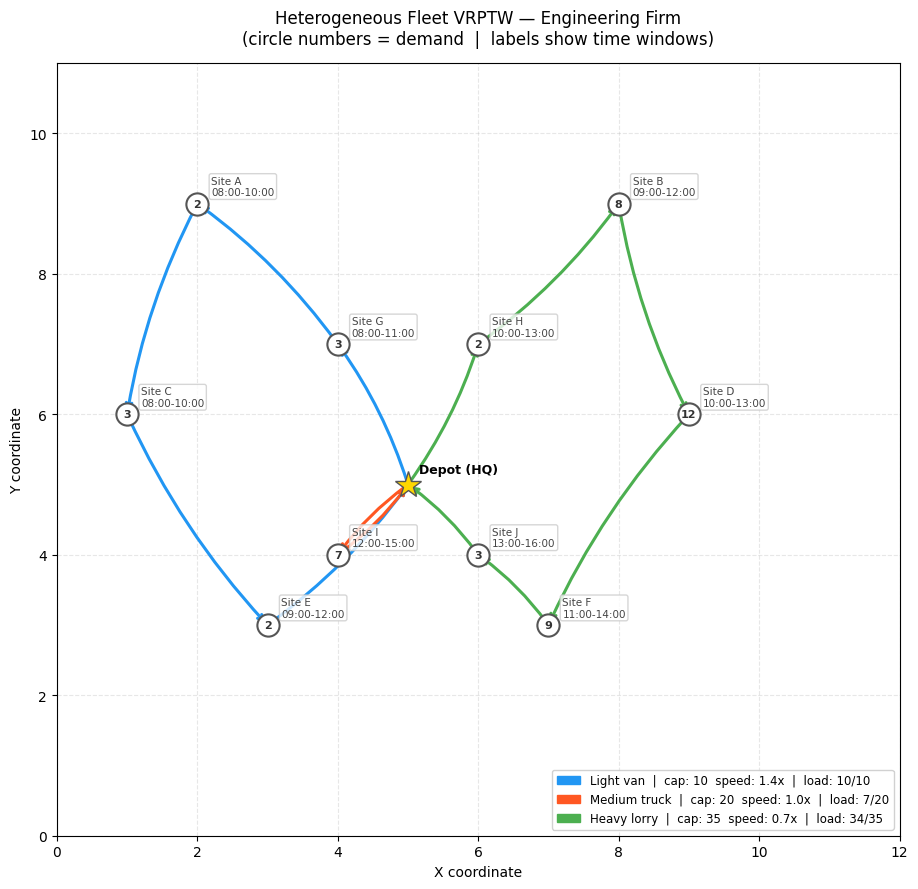

In [13]:
# ------------------------------------------------------------
# STEP 9: SOLVE
# ------------------------------------------------------------
print("Solving heterogeneous fleet VRPTW...")
solution = routing.SolveWithParameters(search_params)

if solution:
    routes = extract_routes(
        data, manager, routing, solution, time_dimension
    )
    print_solution(data, routes)
    visualize_routes(data, routes)
else:
    print("No solution found.")
    print("Try: widening time windows or adjusting vehicle capacities.")


# ------------------------------------------------------------
# ENTRY POINT
# ------------------------------------------------------------